In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
# 2. Importar la función de distancia desde tu código fuente
from src.data_process.time_series_distances import dtw_distance
import math

# 3. Definir la carpeta base
carpeta_datos = Path(r"D:\ProyectoAnalisisElectrico\DiaPromedio\Periodos\2505_2604")

# 4. Cargar la versión PORCENTUAL
print("Cargando versión Porcentual...")
df_centros_pct = pd.read_parquet(carpeta_datos / "2505_2604_centroids_porcentual.parquet")
df_clusterizado_pct = pd.read_parquet(carpeta_datos / "2505_2604_clustered_porcentual.parquet")

# 5. Cargar la versión Z-SCORE
print("Cargando versión Z-Score...")
df_centros_z = pd.read_parquet(carpeta_datos / "2505_2604_centroids_z.parquet")
df_clusterizado_z = pd.read_parquet(carpeta_datos / "2505_2604_clustered_z.parquet")

# 6. Configurar el estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)


Cargando versión Porcentual...
Cargando versión Z-Score...


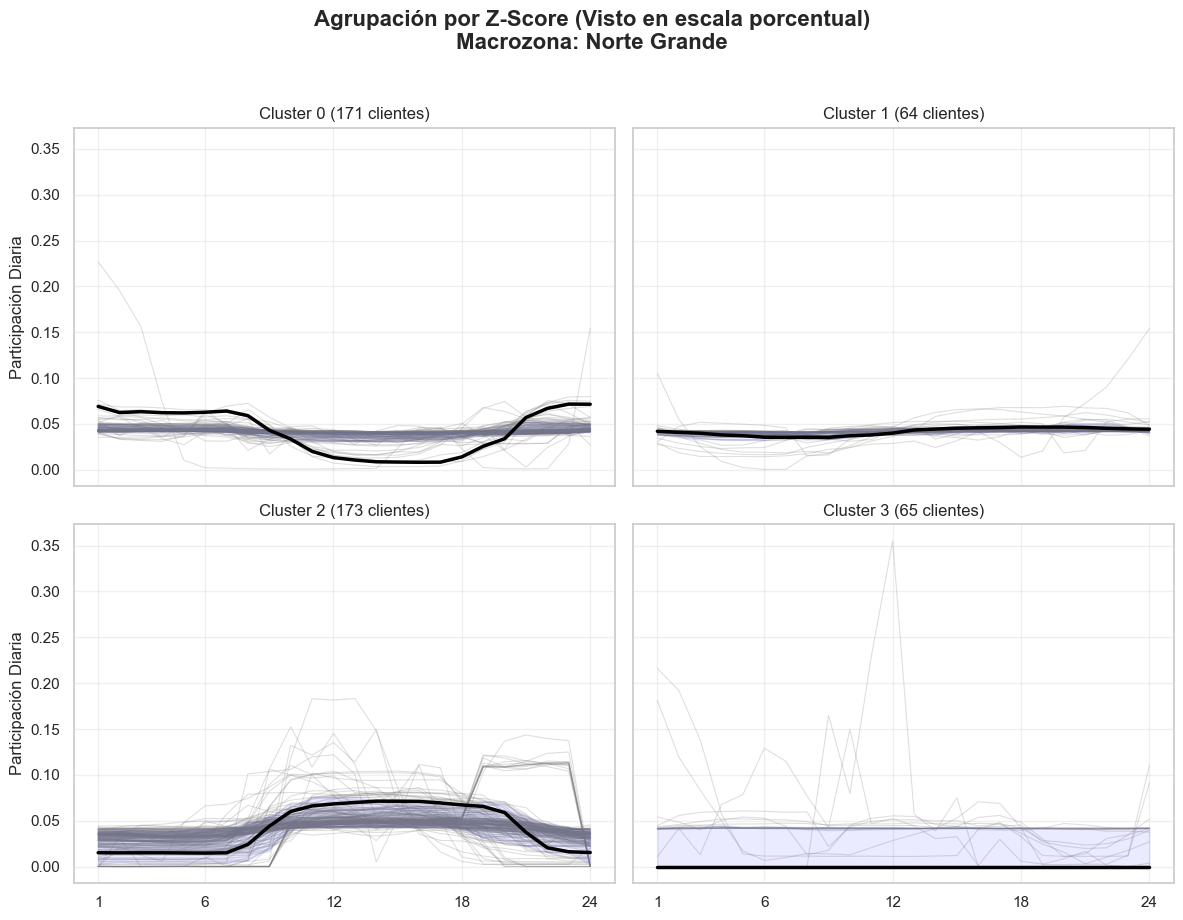

In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. FUNCIÓN DEFINITIVA CON SMART GRID
# ==============================================================================
def plot_all_clusters(df_data, df_centroids, macrozona, col_medida, titulo_principal):
    clusters = sorted(df_centroids[df_centroids["macrozona"] == macrozona]["id_cluster"].unique())
    n_clusters = len(clusters)
    
    if n_clusters == 0:
        print(f"No se encontraron clústeres para {macrozona}.")
        return

    # >>> LA LÓGICA DE LA SMART GRID <<<
    if n_clusters <= 3:
        n_cols, n_rows = n_clusters, 1
    elif n_clusters == 4:
        n_cols, n_rows = 2, 2  # <-- Aquí está la clave para que sea un cuadrado perfecto
    elif n_clusters in [5, 6]:
        n_cols, n_rows = 3, 2
    elif n_clusters in [7, 8]:
        n_cols, n_rows = 4, 2
    else:
        n_cols = 3 if n_clusters <= 9 else 4
        n_rows = math.ceil(n_clusters / n_cols)

    fig_width = max(12, 5 * n_cols)
    fig_height = 4.5 * n_rows
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height), sharex=True, sharey=True)
    fig.suptitle(f"{titulo_principal}\nMacrozona: {macrozona}", fontsize=16, fontweight='bold', y=1.05 if n_rows == 1 else 1.02)
    
    axes = np.array(axes).flatten() if n_clusters > 1 else [axes]
    horas = np.arange(1, 25)

    for i, cluster in enumerate(clusters):
        ax = axes[i]
        
        miembros = df_data[(df_data["macrozona"] == macrozona) & (df_data["id_cluster"] == cluster)]
        centro = df_centroids[(df_centroids["macrozona"] == macrozona) & (df_centroids["id_cluster"] == cluster)]
        
        clave_medoid = centro["clave_medoid"].iloc[0]
        n_miembros = miembros["clave"].nunique()

        # 1. Recopilar todas las curvas en una matriz para la estadística
        # === INICIO MODIFICACIÓN PARA COMBINAR FANTASMA + BANDA DENSIDAD ===
        
        # === INICIO MODIFICACIÓN PARA LÍNEAS FANTASMA BIEN VISIBLES + BANDA ===
        
        curvas_miembros = []
        horas = np.arange(1, 25)

        # 1. Graficar líneas fantasma individuales (Dándoles mucha más visibilidad)
        # Cambiamos alpha de 0.03 a 0.25 (más opaco) y linewidth de 0.5 a 0.8 (más grueso)
        # Esto hará que las líneas con picos locos se vean claramente romper la uniformidad
        for cliente in miembros["clave"].unique():
            curva = miembros[miembros["clave"] == cliente].sort_values("Hora")[col_medida].to_numpy()
            curvas_miembros.append(curva)
            ax.plot(horas, curva, color='gray', alpha=0.25, linewidth=0.8, zorder=1)
        
        curvas_miembros = np.array(curvas_miembros)

        # 2. Calcular Percentiles centrales (Banda de Densidad del 80%)
        # Mantenemos esto para ver el 'núcleo' del grupo
        if n_miembros > 2:
            p10 = np.percentile(curvas_miembros, 10, axis=0)
            p90 = np.percentile(curvas_miembros, 90, axis=0)

            # 3. Dibujar la sombra de densidad (Bajamos un poco su alpha para que no tape las líneas)
            ax.fill_between(horas, p10, p90, color='blue', alpha=0.08, zorder=2, label='Núcleo central 80%')

        # 4. Graficar el Centroide (Medoid) remarcado y encima de todo
        curva_medoid = miembros[miembros["clave"] == clave_medoid].sort_values("Hora")[col_medida].to_numpy()
        ax.plot(horas, curva_medoid, color='black', linewidth=2.5, zorder=5, label=f'Representante')
        
        # === FIN MODIFICACIÓN ===
        
        # === FIN MODIFICACIÓN ===

        ax.set_title(f"Cluster {cluster} ({n_miembros} clientes)")
        ax.set_xticks([1, 6, 12, 18, 24])
        ax.grid(True, alpha=0.3)
        if i % n_cols == 0:
            ax.set_ylabel("Participación Diaria")
        
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

# ==============================================================================
# 2. EJECUTAR EL GRÁFICO (Z-SCORE)
# ==============================================================================
mz_analisis = "Norte Grande"
plot_all_clusters(
    df_data=df_clusterizado_z, 
    df_centroids=df_centros_z, 
    macrozona=mz_analisis, 
    col_medida="medida_porcentual", 
    titulo_principal="Agrupación por Z-Score (Visto en escala porcentual)"
)

Generando visualización panorámica para NORMALIZACIÓN POR SUMA (Macrozona: Norte Grande)...


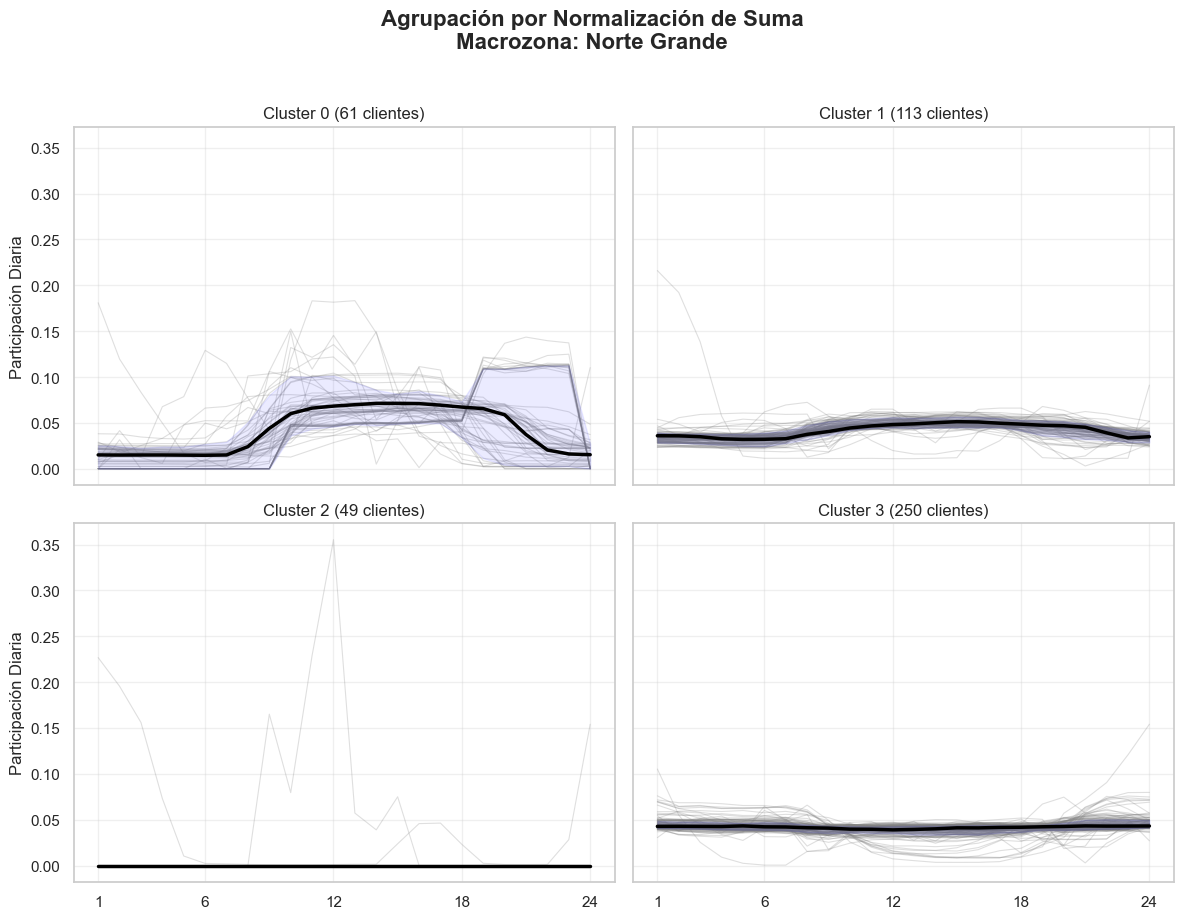

In [16]:
# ==============================================================================
# EJECUTAR GRÁFICO NORMALIZACIÓN POR SUMA
# ==============================================================================
print(f"Generando visualización panorámica para NORMALIZACIÓN POR SUMA (Macrozona: {mz_analisis})...")

plot_all_clusters(
    df_data=df_clusterizado_pct, 
    df_centroids=df_centros_pct, 
    macrozona=mz_analisis, 
    col_medida="medida_porcentual", 
    titulo_principal="Agrupación por Normalización de Suma"
)

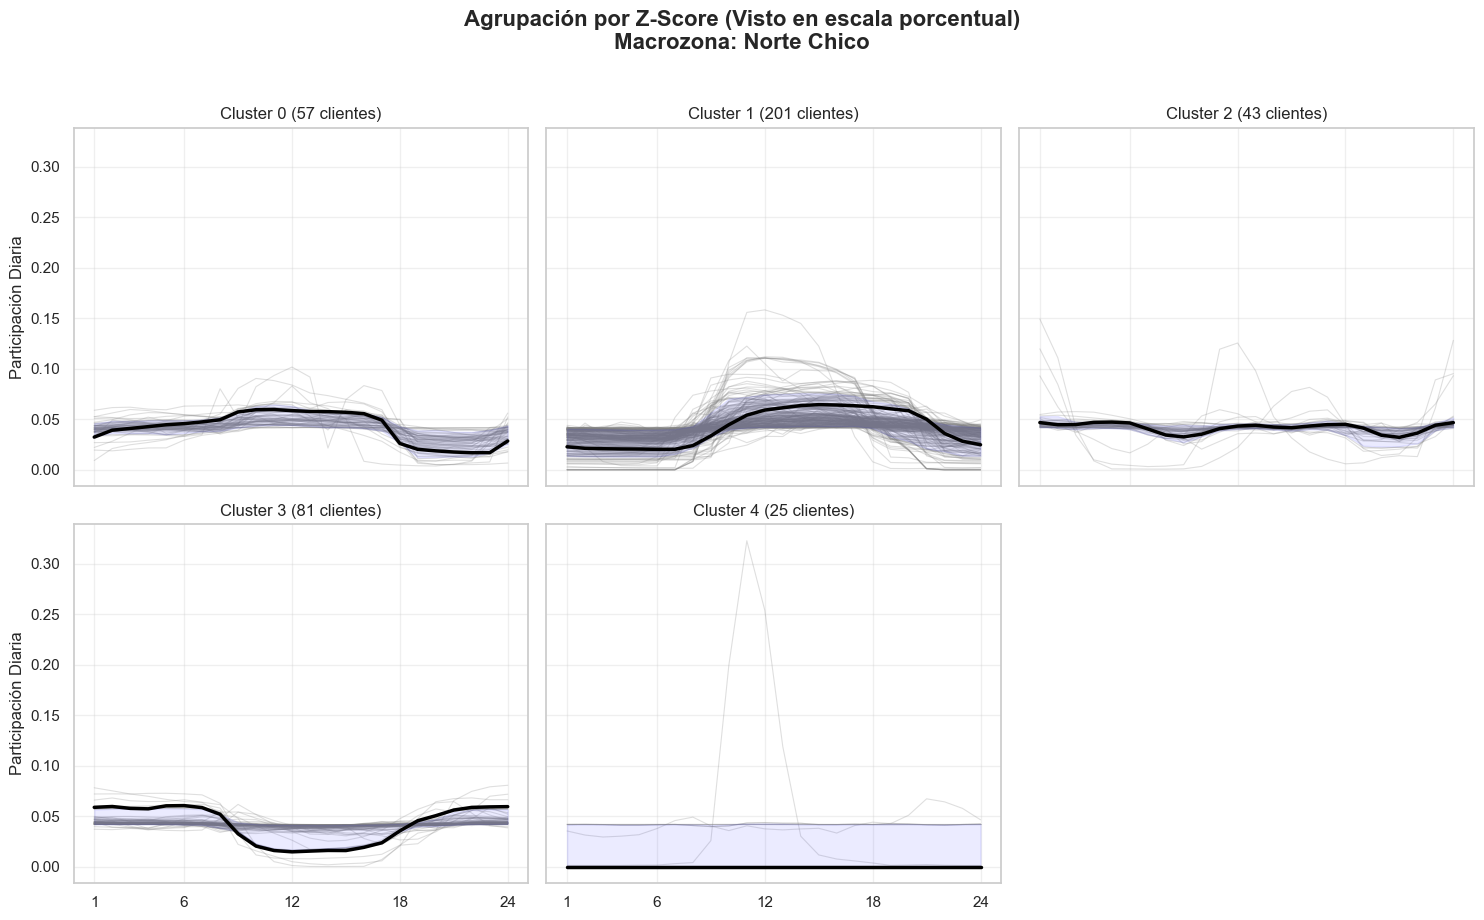

In [17]:
plot_all_clusters(
    df_data=df_clusterizado_z, 
    df_centroids=df_centros_z, 
    macrozona="Norte Chico", 
    col_medida="medida_porcentual", 
    titulo_principal="Agrupación por Z-Score (Visto en escala porcentual)"
)

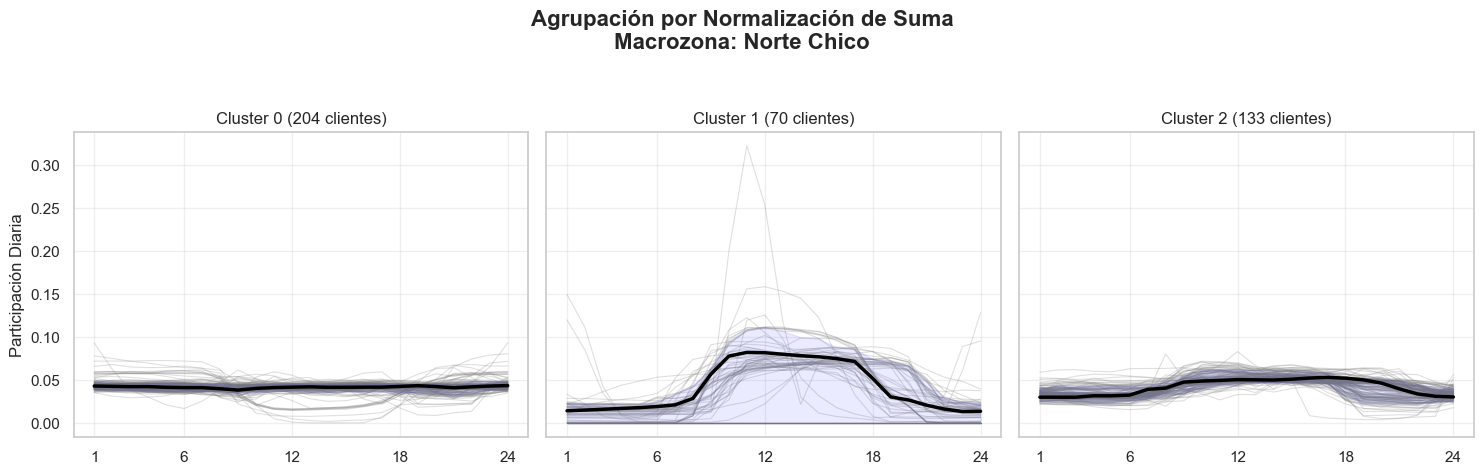

In [18]:
plot_all_clusters(
    df_data=df_clusterizado_pct, 
    df_centroids=df_centros_pct, 
    macrozona="Norte Chico", 
    col_medida="medida_porcentual", 
    titulo_principal="Agrupación por Normalización de Suma"
)